In [2]:
!pip install zarr
import os
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 87.2 MB/s eta 0:00:00


In [3]:
import zarr

# Replace this with an actual folder name from your downloaded dataset
sample_zarr_path = '/content/drive/MyDrive/BioHUB/dataset/train/6bba_0e7c0d07.zarr'

# Open the zarr directory (read-only mode)
image_volume = zarr.open(sample_zarr_path, mode='r')

# The description says the actual image data is inside a folder named '0'
video_data = image_volume['0']

print("Data shape (Time, Z, Y, X):", video_data.shape)
print("Data type:", video_data.dtype)

# To load just the FIRST timepoint into RAM as a NumPy array:
first_frame_3d = video_data[0, :, :, :]

Data shape (Time, Z, Y, X): (100, 64, 256, 256)
Data type: uint16


In [ ]:
first_frame_3d.shape

(64, 256, 256)

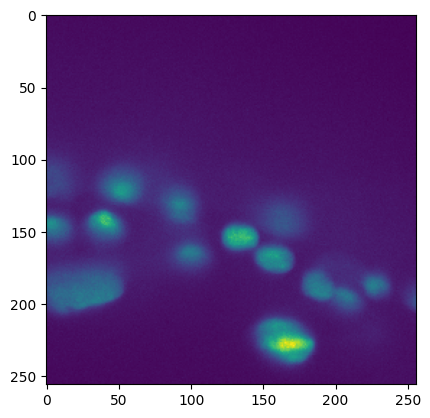

In [12]:
plt.imshow(first_frame_3d[0,:,:])

In [8]:
sample_geff_path = '/content/drive/MyDrive/BioHUB/dataset/train/6bba_0e7c0d07.geff'
graph_data = zarr.open(sample_geff_path, mode='r')

# Load Node IDs
node_ids = graph_data['nodes/ids'][:]

# Load Coordinates for those nodes (Time, Z, Y, X)
t_coords = graph_data['nodes/props/t/values'][:]
z_coords = graph_data['nodes/props/z/values'][:]
y_coords = graph_data['nodes/props/y/values'][:]
x_coords = graph_data['nodes/props/x/values'][:]

# Load Edges (How cells connect frame-to-frame)
edges = graph_data['edges/ids'][:]

print(f"Loaded {len(node_ids)} cell detections and {len(edges)} temporal links.")

Loaded 209 cell detections and 198 temporal links.


In [28]:
node_ids

array([ 1000002,  2000006,  3000012,  4000017,  5000021,  5000022,
        6000027,  6000030,  7000033,  7000036,  8000039,  8000042,
        9000044,  9000047, 10000049, 10000052, 11000054, 11000056,
       12000059, 12000061, 13000064, 13000065, 13000067, 13000068,
       14000069, 14000070, 14000071, 14000072, 15000073, 15000074,
       15000075, 15000076, 16000077, 16000078, 16000079, 16000080,
       16000081, 17000082, 17000083, 17000084, 17000085, 17000086,
       18000087, 18000088, 18000091, 18000092, 18000093, 18000094,
       19000095, 19000096, 19000097, 19000098, 19000099, 19000100,
       20000101, 20000102, 20000103, 20000104, 20000105, 20000106,
       21000107, 21000108, 21000109, 21000110, 21000111, 21000112,
       22000113, 22000114, 22000115, 22000116, 22000117, 22000118,
       23000119, 23000120, 23000121, 23000122, 23000123, 24000124,
       24000125, 24000127, 24000128, 25000129, 25000131, 25000132,
       25000133, 26000134, 26000137, 26000138, 26000139, 27000

In [26]:
t_coords


array([ 0,  1,  2,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8,  9,  9, 10,
       10, 11, 11, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 15, 15,
       15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21,
       21, 21, 21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 24, 24, 24, 24,
       25, 25, 25, 25, 26, 26, 26, 27, 27, 27, 28, 28, 28, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 39, 40, 40, 41, 41, 42, 42, 43, 43, 44, 44, 45,
       45, 46, 46, 47, 47, 48, 48, 49, 49, 50, 50, 51, 51, 52, 52, 53, 53,
       54, 54, 55, 55, 56, 56, 57, 57, 58, 58, 59, 59, 60, 61, 61, 62, 62,
       63, 63, 64, 64, 65, 65, 66, 66, 67, 67, 68, 69, 70, 71, 72, 73, 73,
       74, 74, 75, 75, 76, 76, 77, 77, 78, 78, 79, 79, 80, 80, 81, 81, 82,
       82, 83, 83, 84, 84, 85, 85, 54, 55, 56, 57, 58, 58, 59, 59, 60, 60,
       68, 69, 70, 71, 72])

In [27]:
x_coords

array([ 23,  31,  37,  53,  63,  48,  72,  52,  78,  56,  86,  56, 100,
        54, 108,  55, 125,  53, 137,  56,   3, 142,  59,   8,   4, 149,
        58,  10,   5, 156,  60,  14,   8, 153, 167,  66,  20,  12, 155,
       177,  70,  25,  17, 158, 184, 170,  75,  34,  17, 158, 192, 170,
        72,  39,  19, 158, 203, 170,  69,  52,  20, 159, 209, 170,  70,
        61, 162, 215,  24, 169,  74,  72, 164, 223,  30, 171,  78, 169,
        39, 172,  84, 173,  45, 176,  88, 181,  53, 183,  93, 187,  62,
       192, 193,  68, 196, 193,  68, 196,   8,  13,  14,  19,  24,  34,
        42,  48, 101,  65, 111,  73, 117,  79, 122,  82, 130,  86, 138,
        92, 144,  98, 151, 105, 158, 110, 167, 118, 174, 124, 180, 129,
       188, 135, 204, 149, 208, 152, 214, 156, 218, 158, 223, 163, 229,
       171, 237, 179, 242, 186, 191,  62, 198,  71, 203,  80, 208,  90,
       215, 100, 224, 111, 228, 111, 228, 123, 130, 137, 147, 155, 163,
       176, 175, 189, 182, 199, 191, 207, 196, 211, 197, 216, 20

In [20]:
len(y_coords), len(x_coords), len(t_coords)

(209, 209, 209)

In [35]:
t_coords

array([ 0,  1,  2,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8,  9,  9, 10,
       10, 11, 11, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 15, 15,
       15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21,
       21, 21, 21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 24, 24, 24, 24,
       25, 25, 25, 25, 26, 26, 26, 27, 27, 27, 28, 28, 28, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 39, 40, 40, 41, 41, 42, 42, 43, 43, 44, 44, 45,
       45, 46, 46, 47, 47, 48, 48, 49, 49, 50, 50, 51, 51, 52, 52, 53, 53,
       54, 54, 55, 55, 56, 56, 57, 57, 58, 58, 59, 59, 60, 61, 61, 62, 62,
       63, 63, 64, 64, 65, 65, 66, 66, 67, 67, 68, 69, 70, 71, 72, 73, 73,
       74, 74, 75, 75, 76, 76, 77, 77, 78, 78, 79, 79, 80, 80, 81, 81, 82,
       82, 83, 83, 84, 84, 85, 85, 54, 55, 56, 57, 58, 58, 59, 59, 60, 60,
       68, 69, 70, 71, 72])

In [36]:
z_coords

array([ 4,  4,  4,  5,  3, 12,  3, 12,  3, 11,  3, 10,  3, 10,  2, 10,  2,
       10,  3, 10,  4,  3, 10, 14,  4,  3, 10, 14,  5,  3, 10, 14,  6,  2,
        3, 11, 14,  6,  3,  3, 11, 14,  6,  2,  3, 10, 11, 14,  6,  2,  3,
       10, 11, 14,  7,  3,  3, 10, 11, 13,  7,  3,  3, 10, 11, 13,  3,  3,
        9, 10, 11, 14,  4,  3, 10, 11, 13,  4, 12, 12, 13,  4, 12, 12, 14,
        4, 13, 12, 14,  5, 14, 13,  4, 14, 13,  4, 14, 13, 17, 20, 21, 22,
       23, 24, 25, 26,  9, 29, 10, 30, 10, 30, 11, 31, 13, 30, 12, 31, 13,
       31, 13, 31, 14, 33, 15, 33, 17, 34, 17, 35, 16, 34, 19, 36, 20, 37,
       20, 38, 20, 39, 21, 39, 22, 39, 22, 39, 22, 40, 41,  4, 42,  5, 42,
        6, 42,  7, 43,  7, 43,  8, 43,  8, 43,  4,  4,  4,  5,  5,  5,  9,
        5,  8,  4,  5,  5,  6,  5,  7,  5,  6,  5,  5,  4,  6,  4,  5,  4,
        5,  4,  5,  4,  5,  5,  3,  6,  6,  6,  7,  9,  7,  9,  8, 10,  8,
        6,  7,  7,  6,  6])

In [45]:
arr = []
for x,y in zip(x_coords, y_coords):
  arr.append((int(x),int(y)))


for i, (t, z) in enumerate(zip(t_coords, z_coords)):
  print(f"t = {t}, z = {z}, coords = {arr[i]}")


t = 0, z = 4, coords = (23, 194)
t = 1, z = 4, coords = (31, 193)
t = 2, z = 4, coords = (37, 192)
t = 3, z = 5, coords = (53, 189)
t = 4, z = 3, coords = (63, 190)
t = 4, z = 12, coords = (48, 177)
t = 5, z = 3, coords = (72, 192)
t = 5, z = 12, coords = (52, 171)
t = 6, z = 3, coords = (78, 193)
t = 6, z = 11, coords = (56, 167)
t = 7, z = 3, coords = (86, 193)
t = 7, z = 10, coords = (56, 166)
t = 8, z = 3, coords = (100, 194)
t = 8, z = 10, coords = (54, 159)
t = 9, z = 2, coords = (108, 195)
t = 9, z = 10, coords = (55, 156)
t = 10, z = 2, coords = (125, 200)
t = 10, z = 10, coords = (53, 153)
t = 11, z = 3, coords = (137, 207)
t = 11, z = 10, coords = (56, 150)
t = 12, z = 4, coords = (3, 109)
t = 12, z = 3, coords = (142, 209)
t = 12, z = 10, coords = (59, 149)
t = 12, z = 14, coords = (8, 236)
t = 13, z = 4, coords = (4, 110)
t = 13, z = 3, coords = (149, 212)
t = 13, z = 10, coords = (58, 149)
t = 13, z = 14, coords = (10, 237)
t = 14, z = 5, coords = (5, 108)
t = 14, z = 3, c

In [7]:
import pandas as pd

# 1. Combine your 1D arrays into a DataFrame (if you haven't already)
nodes_df = pd.DataFrame({
    't': t_coords,
    'z': z_coords,
    'y': y_coords,
    'x': x_coords
})

# 2. Group by BOTH time (t) and depth (z), then count them
slice_counts = nodes_df.groupby(['t', 'z']).size().reset_index(name='cell_count')

# 3. Sort to find the slices with the maximum number of annotations
busiest_slices = slice_counts.sort_values(by='cell_count', ascending=False)

print("The Top 5 Busiest Slices in the Ground Truth:")
print("-" * 45)
print(busiest_slices.head())

The Top 5 Busiest Slices in the Ground Truth:
---------------------------------------------
     t   z  cell_count
63  21   3           2
37  16   3           2
53  19   3           2
58  20   3           2
77  24  12           2


## Cell coordinates plot with the most annotations

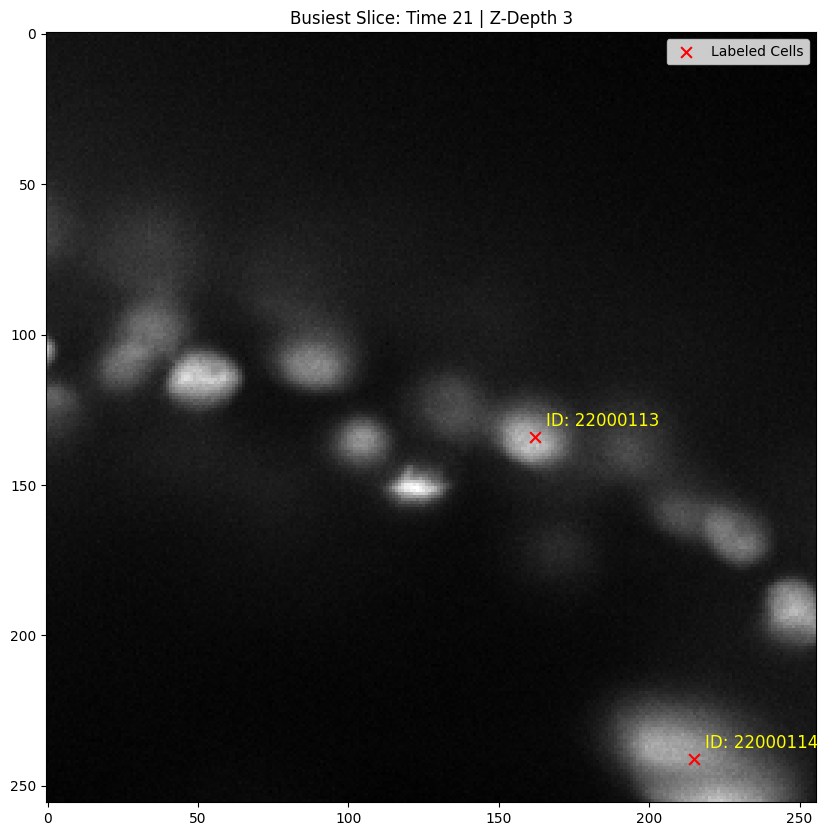

In [9]:
# 1. Set our targets to the #1 busiest slice you just found
target_t = 21
target_z = 3

# 2. Extract the raw image slice
exact_slice = video_data[target_t, target_z, :, :]

# 3. Create a mask to pull out JUST those 2 cells
mask = (t_coords == target_t) & (z_coords == target_z)

slice_x = x_coords[mask]
slice_y = y_coords[mask]
slice_ids = node_ids[mask]

# 4. Plot
plt.figure(figsize=(10, 10))
plt.imshow(exact_slice, cmap='gray')

plt.scatter(
    slice_x,
    slice_y,
    c='red',
    s=60,
    marker='x',
    label='Labeled Cells'
)

# Label the two cells with their IDs so you can see which is which
for i, txt in enumerate(slice_ids):
    plt.annotate(
        f"ID: {txt}",
        (slice_x.iloc[i] if isinstance(slice_x, pd.Series) else slice_x[i],
         slice_y.iloc[i] if isinstance(slice_y, pd.Series) else slice_y[i]),
        color='yellow',
        fontsize=12,
        xytext=(8, 8),
        textcoords='offset points'
    )

plt.title(f"Busiest Slice: Time {target_t} | Z-Depth {target_z}")
plt.legend()
plt.show()

## Run Watershed to isolate components


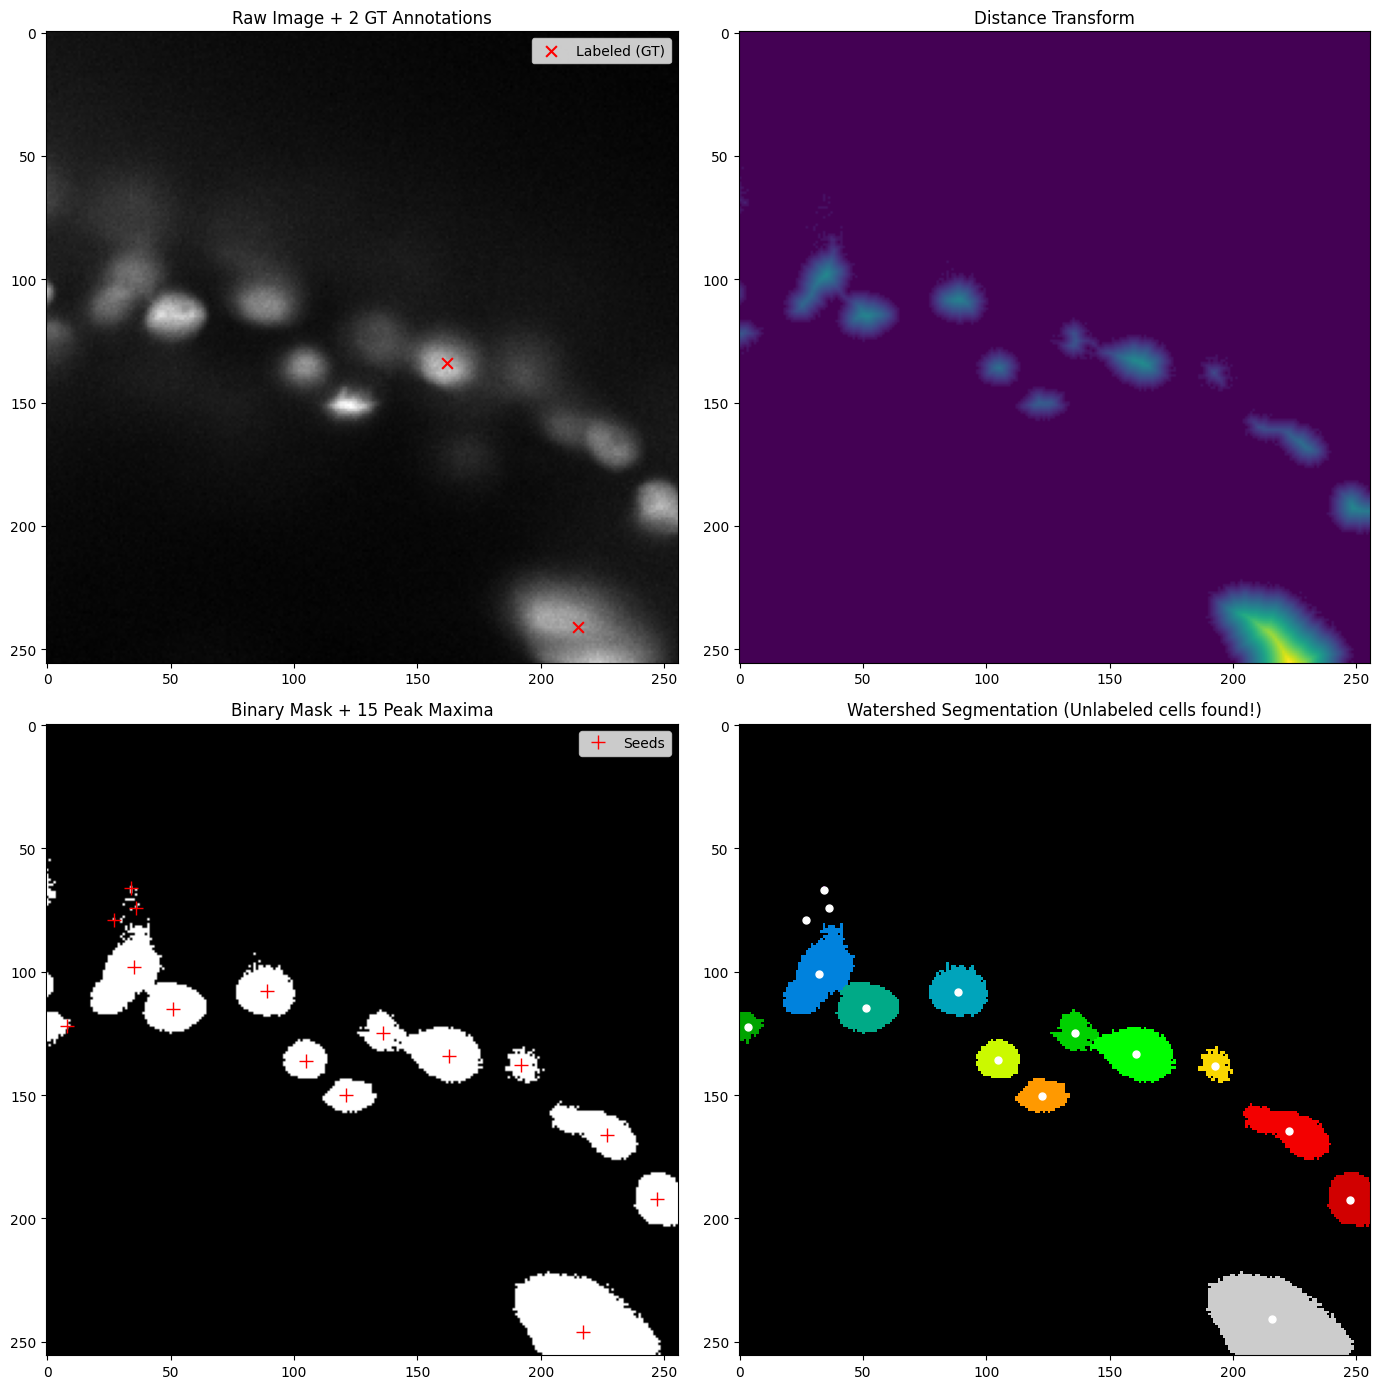

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import label, regionprops
from scipy import ndimage as ndi

# 1. Extract the raw slice (assuming video_data is loaded)
target_t = 21
target_z = 3
raw_image = video_data[target_t, target_z, :, :]

# Normalize the image for better thresholding (important for uint16/uint8)
img_norm = (raw_image - np.min(raw_image)) / (np.max(raw_image) - np.min(raw_image) + 1e-8)

# 2. Otsu Thresholding (Binary Foreground Mask)
thresh = threshold_otsu(img_norm)
binary_mask = img_norm > thresh

# 3. Distance Transform
# Calculates how far every foreground pixel is from the nearest background pixel
distance = ndi.distance_transform_edt(binary_mask)

# 4. Peak-Local-Max (Find the seeds)
# min_distance controls how close two cells can be before they are merged
coords = peak_local_max(distance, min_distance=8, labels=binary_mask)

# Create a blank marker array and place the seeds
markers = np.zeros(distance.shape, dtype=bool)
markers[tuple(coords.T)] = True
# Label the markers with unique integers for the watershed
markers_labeled, num_features = ndi.label(markers)

# 5. Watershed Segmentation
# "Flood" the distance transform starting from the seeds, constrained by the mask
labels = watershed(-distance, markers_labeled, mask=binary_mask)

# 6. Extract the Centroids of the newly segmented unlabeled cells
segmented_centroids = []
for region in regionprops(labels):
    # regionprops returns (row, col) which is (y, x)
    segmented_centroids.append((region.centroid[1], region.centroid[0])) # Append (x, y)

# 7. Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
ax = axes.ravel()

# Plot A: The Raw Image with the 2 Ground Truth Nodes
ax[0].imshow(raw_image, cmap='gray')
ax[0].scatter(slice_x, slice_y, c='red', s=60, marker='x', label='Labeled (GT)')
ax[0].set_title('Raw Image + 2 GT Annotations')
ax[0].legend()

# Plot B: Distance Transform
ax[1].imshow(distance, cmap='viridis')
ax[1].set_title('Distance Transform')

# Plot C: The Local Maxima (Seeds)
ax[2].imshow(binary_mask, cmap='gray')
ax[2].plot(coords[:, 1], coords[:, 0], 'r+', markersize=10, label='Seeds')
ax[2].set_title(f'Binary Mask + {num_features} Peak Maxima')
ax[2].legend()

# Plot D: The Watershed Result + All Found Centroids
# The watershed labels are plotted with the 'nipy_spectral' colormap for distinction
ax[3].imshow(labels, cmap='nipy_spectral', interpolation='nearest')
for cx, cy in segmented_centroids:
    ax[3].plot(cx, cy, 'wo', markersize=5) # White circles for found centroids
ax[3].set_title('Watershed Segmentation (Unlabeled cells found!)')

plt.tight_layout()
plt.show()

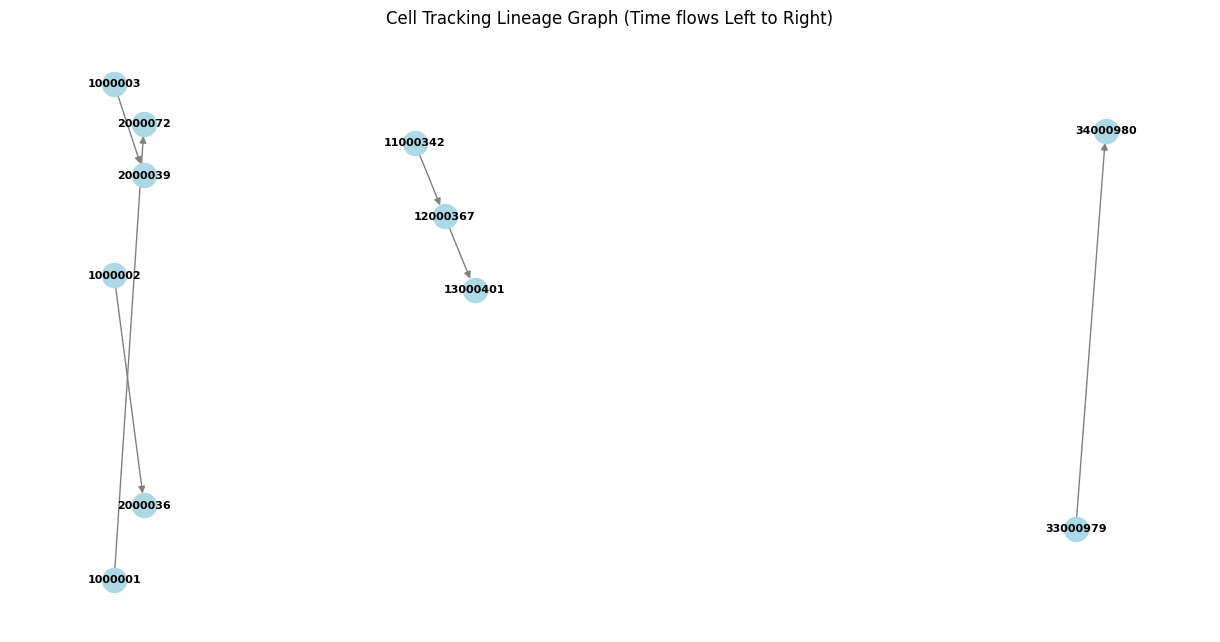

In [ ]:

# Assuming 'edges_array' is your actual loaded numpy array from the .geff file
# For this example, I am using the exact snippet you provided
edges_array = np.array([
    [ 1000001,  2000072],
    [ 1000002,  2000036],
    [ 1000003,  2000039],
    [11000342, 12000367],
    [12000367, 13000401],
    [33000979, 34000980]
], dtype=np.uint64)

# 1. Create the directed graph
G = nx.DiGraph()
G.add_edges_from(edges_array)

# 2. Extract the 'Timepoint' from the Node ID to use as the X-coordinate
# We divide by 1,000,000 to get the prefix (e.g., 12000367 // 1000000 = 12)
pos = {}
for node in G.nodes():
    time_frame = node // 1000000

    # Assign X to time_frame, and random Y to spread them out vertically
    pos[node] = (time_frame, np.random.rand())

# 3. Plot the graph
plt.figure(figsize=(12, 6))
nx.draw(G, pos,
        node_size=300,
        node_color='lightblue',
        edge_color='gray',
        with_labels=True,
        font_size=8,
        font_weight='bold',
        arrows=True)

plt.title("Cell Tracking Lineage Graph (Time flows Left to Right)")
plt.xlabel("Timepoint (Extracted from ID prefix)")
plt.show()

In [ ]:
edges

array([[ 1000001,  2000072],
       [ 1000002,  2000036],
       [ 1000003,  2000039],
       ...,
       [12000367, 13000401],
       [11000342, 12000367],
       [33000979, 34000980]], dtype=uint64)

Min Intensity: 2
Max Intensity: 1095
Mean Intensity: 49.33


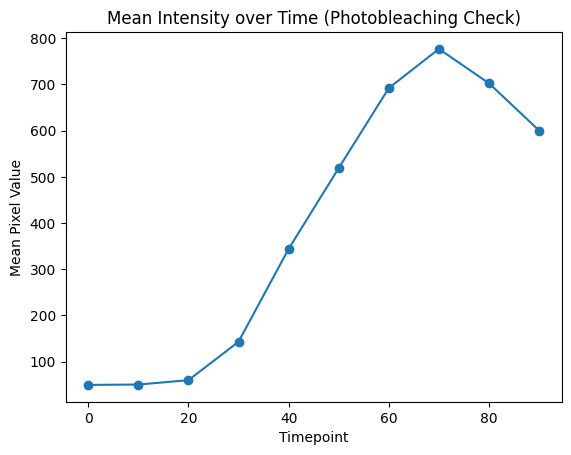

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Quick check on a single timepoint (e.g., t=0)
frame_data = video_data[0, :, :, :]

print(f"Min Intensity: {frame_data.min()}")
print(f"Max Intensity: {frame_data.max()}")
print(f"Mean Intensity: {frame_data.mean():.2f}")

# Plotting intensity over time to check for photobleaching
means_over_time = [video_data[t, :, :, :].mean() for t in range(0, video_data.shape[0], 10)]
plt.plot(range(0, video_data.shape[0], 10), means_over_time, marker='o')
plt.title("Mean Intensity over Time (Photobleaching Check)")
plt.xlabel("Timepoint")
plt.ylabel("Mean Pixel Value")
plt.show()

In [ ]:
import numpy as np

# Let's say we are looking at the first 3D frame
frame = video_data[0, :, :, :]

# Rough estimate: The top 1% of brightest pixels are "cells"
threshold = np.percentile(frame, 99)

# Separate the image into signal (cells) and background
signal_pixels = frame[frame > threshold]
background_pixels = frame[frame <= threshold]

# Calculate the components
mu_signal = signal_pixels.mean()
mu_background = background_pixels.mean()
sigma_background = background_pixels.std()

# Calculate SNR
snr = (mu_signal - mu_background) / sigma_background

print(f"Mean Signal: {mu_signal:.2f}")
print(f"Mean Background: {mu_background:.2f}")
print(f"Background Noise (Std Dev): {sigma_background:.2f}")
print(f"Estimated SNR: {snr:.2f}")

Mean Signal: 491.21
Mean Background: 44.88
Background Noise (Std Dev): 41.33
Estimated SNR: 10.80


## GNN model testing

In [ ]:
!pip install torch torchvision torchaudio
!pip install torch_geometric

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import KarateClub
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv

# ==========================================
# 1. Load Data & Prepare Link Prediction
# ==========================================
# The Karate Club dataset is a small social network of 34 members.
dataset = KarateClub()
data = dataset[0]

# For link prediction, we need to hide some edges to test if our model can predict them.
# We also need "negative edges" (pairs of people who aren't friends) to teach the model
# what a non-link looks like. RandomLinkSplit handles all of this automatically!
transform = RandomLinkSplit(
    num_val=0.1,       # 10% of edges for validation
    num_test=0.1,      # 10% of edges for testing
    is_undirected=True # Social network friendships are mutual
)
train_data, val_data, test_data = transform(data)

# ==========================================
# 2. Define the GNN Model
# ==========================================
class SocialLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Two Graph Convolutional Layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, x, edge_index):
        # The ENCODER: Learns user embeddings based on their network neighborhood
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

    def decode(self, z, edge_label_index):
        # The DECODER: Takes two user embeddings and takes the dot product
        # A higher dot product means a higher chance they are/should be friends
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)

# Initialize the model, optimizer, and loss function
model = SocialLinkPredictor(dataset.num_features, 16, 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss() # Binary Cross Entropy for Yes/No link prediction

# ==========================================
# 3. Training Loop
# ==========================================
def train():
    model.train()
    optimizer.zero_grad()

    # 1. Encode the graph (pass the known training edges to get embeddings)
    z = model.encode(train_data.x, train_data.edge_index)

    # 2. Decode the probabilities (guess friendships for the training edge labels)
    # Note: edge_label_index contains both real friendships (1s) and fake friendships (0s)
    out = model.decode(z, train_data.edge_label_index)
    print(len(out))
    print()
    print(train_data.edge_label)
    return

    # 3. Calculate loss and update weights
    loss = criterion(out, train_data.edge_label)
    loss.backward()
    optimizer.step()

    return loss.item()

print("Starting training...")
for epoch in range(1, 101):
    loss = train()
    break
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")